# Priors...tell me more...

A lot of people first considering Bayesian work are freaked out by priors. Where do they come from? Are they philosophically reasonable? What if they're wrong? I've never needed them in regular (i.e. frequentist) work, why do I have to have them now?

In this notebook, you will learn (via claim-and-point-to-papers, as well as empirically by exmample; *not* through proofs or forumals):
* Priors (and Bayesian analysis) are philosohpically _correct_
* Priors come from your brain, related literature, experts, and other places
* You have always used priors in your DS work, they've just been really specific and unstated
* Sometimes your choice of prior matters substantively
* Families of methods for assessing the sensitivity of findings to priors

If this all sounds like coursework, don't fret. It's (as ever) light on theory, and heavy on pointers (to real literature) and empirical examples in code for you to leverage in your work.


# Bayesian Inference

At the core of Bayesian inference is updating knowledge. This assumes that we have something to update from (prior distributions, or just 'priors'), something to update to (posterior distributions, or simply 'posteriors'), some evidence (that's typically a likelihood or likelihood function, estimated from data), and a mathematical mechanism for turning priors and evidence into posteriors.

Bayesian inference includes the tools for turning priors and new evidence into posteriors in a very satisfying, rigorous way. More certain priors require stronger (larger, and more consistent) evidence to lead to meaningfully different posteriors. Said differently, Bayesian inference allows us to nicely account for beliefs, evidentiary strength, and uncertainty in beliefs, evidence, and updated beliefs.

# On Priors, Extremely Briefly

Priors can come from anywhere. They can be (well or badly) made up by a researcher, distilled from a literature review (qualitatively or quantitatively), derived from expert elicitation, or set to a consensus field standard. If that sounds "made up" and you feel like you haven't needed priors before to, for instance, estimate OLS coefficients, you're in for a shock: you DID have priors when you called OLS, they were just strongly assumed (in form) and hence were unstated assumptions. Forcing resaerchers to specify them isn't "made up" but rather forces transparency. 

# Priors, Evidence, and Posteriors

Roughly, we can think of posteriors as being prior distributions multiplied by evidence distributions (e.g. likelihood functions). "Strong" or "tight" or "informative" priors (i.e. narrow distributions describing our pre-evidence beliefs about parameter size) require stronger evidence (i.e. divergent and specific distributions of estimated effects) to reshape our posteriors. Below, we get into this empirically.


# Setup
Suppose we want to estimate an Ordinarly Least Squares (OLS, or "linear model") style regression. For simplicity, let's assume homoskedasticity, and a one-covariate plus intercept setup. What happens if we have very vague/uninformative priors and little evidence? Strong priors and little evidence? Vague priors and strong evidence? Strong priors and strong evidence? What happens in those cases when our evidence roughly matches our priors? When it does not? Each cell below sets up one of these cases and works through it. First, you'll see a cell labeled plotting helper. It helps making nice viz of the priors we'll choose, the likelihoods (conditional likelihoods, really), and the posteriors.

Notation:
alpha = intercept term
beta = slope term
sigma = conditional variance of y (conditioned on x)
true_* prefix = simulated data setup
n = number of observations

If you're used to y=mx+b setup, this can be confusing...in most stats courses, betas are slope terms in regressions (insead of x) and alphas are often intercepts (instead of b).

In [11]:
# PLOTTING HELPER
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

def plot_prior_likelihood_posterior_linear(
    trace,
    x,
    y,
    alpha_prior_mu,
    alpha_prior_sigma,
    beta_prior_mu,
    beta_prior_sigma,
    grid_points=400,
    zoom_sd=4
):

    alpha_post = trace.posterior["alpha"].values.flatten()
    beta_post = trace.posterior["beta"].values.flatten()

    # Posterior stats
    alpha_mean = np.mean(alpha_post)
    alpha_sd = np.std(alpha_post)

    beta_mean = np.mean(beta_post)
    beta_sd = np.std(beta_post)

    # Restrict plotting range around posterior
    alpha_grid = np.linspace(
        alpha_mean - zoom_sd * alpha_sd,
        alpha_mean + zoom_sd * alpha_sd,
        grid_points
    )

    beta_grid = np.linspace(
        beta_mean - zoom_sd * beta_sd,
        beta_mean + zoom_sd * beta_sd,
        grid_points
    )

    # OLS estimates for likelihood
    ols_beta, ols_alpha = np.polyfit(x, y, 1)
    resid = y - (ols_alpha + ols_beta * x)
    sigma = np.std(resid, ddof=2)

    # Priors
    alpha_prior = norm.pdf(alpha_grid, alpha_prior_mu, alpha_prior_sigma)
    beta_prior = norm.pdf(beta_grid, beta_prior_mu, beta_prior_sigma)

    # Likelihood for alpha (beta fixed at OLS)
    alpha_like = []
    for a in alpha_grid:
        mu = a + ols_beta * x
        ll = np.sum(norm.logpdf(y, mu, sigma))
        alpha_like.append(ll)
    alpha_like = np.exp(alpha_like - np.max(alpha_like))

    # Likelihood for beta (alpha fixed at OLS)
    beta_like = []
    for b in beta_grid:
        mu = ols_alpha + b * x
        ll = np.sum(norm.logpdf(y, mu, sigma))
        beta_like.append(ll)
    beta_like = np.exp(beta_like - np.max(beta_like))

    # Posterior KDEs
    alpha_post_kde = gaussian_kde(alpha_post)
    beta_post_kde = gaussian_kde(beta_post)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Alpha panel
    ax[0].plot(alpha_grid, alpha_prior, label="Prior")
    ax[0].plot(alpha_grid, alpha_like, label="Likelihood")
    ax[0].plot(alpha_grid, alpha_post_kde(alpha_grid), label="Posterior")
    ax[0].set_title("alpha")
    ax[0].legend()

    # Beta panel
    ax[1].plot(beta_grid, beta_prior, label="Prior")
    ax[1].plot(beta_grid, beta_like, label="Likelihood")
    ax[1].plot(beta_grid, beta_post_kde(beta_grid), label="Posterior")
    ax[1].set_title("beta")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, beta, sigma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


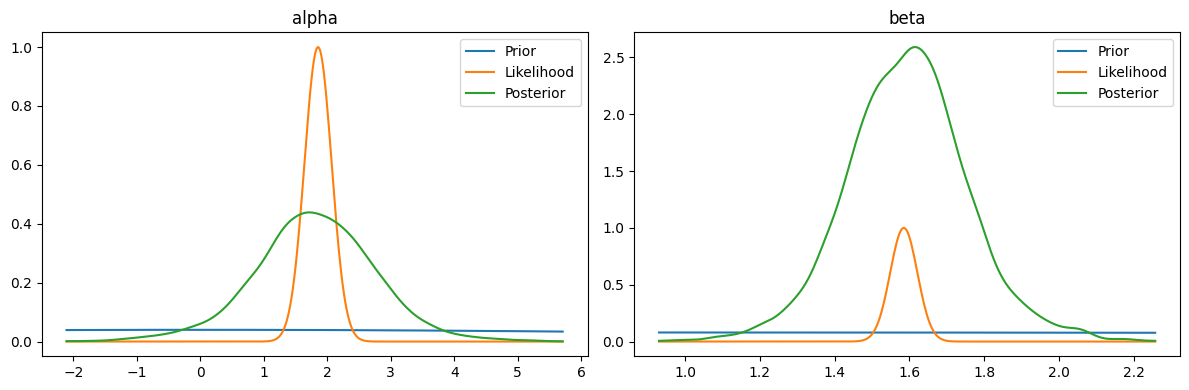

In [15]:
# Vague priors, strong evidence, evidence consistent with priors
import numpy as np # for random numbers
import pymc as pm # for bayesian MCMC
import arviz as az # for 

rng = np.random.default_rng(99)

# Let's imagine a true data-generating process (DGP) with strong evidence 
#    (plenty of consistent evidence, low noise)
# Let's shape vague priors, and see what happens

true_alpha = 2.0 # real (simulated) intercept is 2
true_beta = 1.5  # real (simulated) slope is 1.5
true_sigma = 1.0 # variance of y conditioned on x has standard deviation of 1.0

# Make up data...as if we observed it from a study.
# 10 samples
n = 10 
# x from a broad swath of space, and drawn uniformly
x = rng.uniform(0, 10, size=n)
# simulated DGP: y is a linear function of b*x, plus alpha, plus noise
y = true_alpha + true_beta * x + rng.normal(0, true_sigma, size=n)

# vague priors that point nowhere, but at least not in the wrong direction
# "direction" in that mu=0, which is not far from the truth
# vague in that the SD is 10, which says "we have no clue where this parameter really lives"
alpha_prior_mu = 0.0
alpha_prior_sigma = 10.0

# similarly vague and directionally right priors for beta
beta_prior_mu = 1.0
beta_prior_sigma = 5.0

with pm.Model() as vague_prior_strong_evidence_model:
    # prior on alpha
    alpha = pm.Normal("alpha", mu=alpha_prior_mu, sigma=alpha_prior_sigma)
    # prior on beta
    beta = pm.Normal("beta", mu=beta_prior_mu, sigma=beta_prior_sigma)
    # prior on sigma
    sigma = pm.HalfNormal("sigma", sigma=5.0)

    # this is the likelihood model
    # it is how your data (x) enters
    # i.e. this is where we setup our linear regression
    mu = alpha + beta * x

    # We think our y data is drawn Noramlly, with mean mu (defined above), and variance sigma
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

    # same sampling stack as in 1_Introduction notebook
    trace_vague_strong_consistent = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=123,
        progressbar=False
    )

# plot the outcomes
plot_prior_likelihood_posterior_linear(
    trace_vague_strong_consistent,
    x,
    y,
    alpha_prior_mu,
    alpha_prior_sigma,
    beta_prior_mu,
    beta_prior_sigma
)

# What Am I Looking At?
